# Feature Selection

After engineering 96 features, the goal here is to check which ones actually carry signal for `is_claim` and drop anything that is just noise or near constant.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_transformation import DataTransformation
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('../data/train.csv')
transformer = DataTransformation(artifacts_dir='../artifacts')
X, y = transformer.fit_transform(df)
print(X.shape, y.shape)

2026-07-18 11:50:56,521 | src.data_transformation | INFO | Fitting data transformation pipeline
2026-07-18 11:50:57,229 | src.data_transformation | INFO | Final feature matrix shape: (58592, 96)


(58592, 96) (58592,)


### Correlation with target

Simple linear correlation is a quick first filter, though it will not catch non-linear relationships (that is what the tree based importance check further down is for).

In [3]:
corr_with_target = X.corrwith(y).sort_values(key=abs, ascending=False)
top_corr = corr_with_target.head(20)
top_corr

policy_tenure                       0.078747
age_of_car                         -0.028172
age_of_policyholder                 0.022435
population_density                 -0.017808
area_cluster_C10                   -0.016630
is_adjustable_steering              0.013917
area_cluster_C14                    0.013511
cylinder                            0.013434
area_cluster_C8                     0.013295
area_cluster_C9                    -0.012860
segment_B2                          0.012714
is_front_fog_lights                 0.011825
area_cluster_C18                    0.011441
area_cluster_C7                    -0.010946
is_brake_assist                     0.010893
is_driver_seat_height_adjustable    0.010686
area_cluster_C2                     0.010607
width                               0.009947
steering_type_Electric              0.009849
area_cluster_C3                     0.009759
dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_5316\569915611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


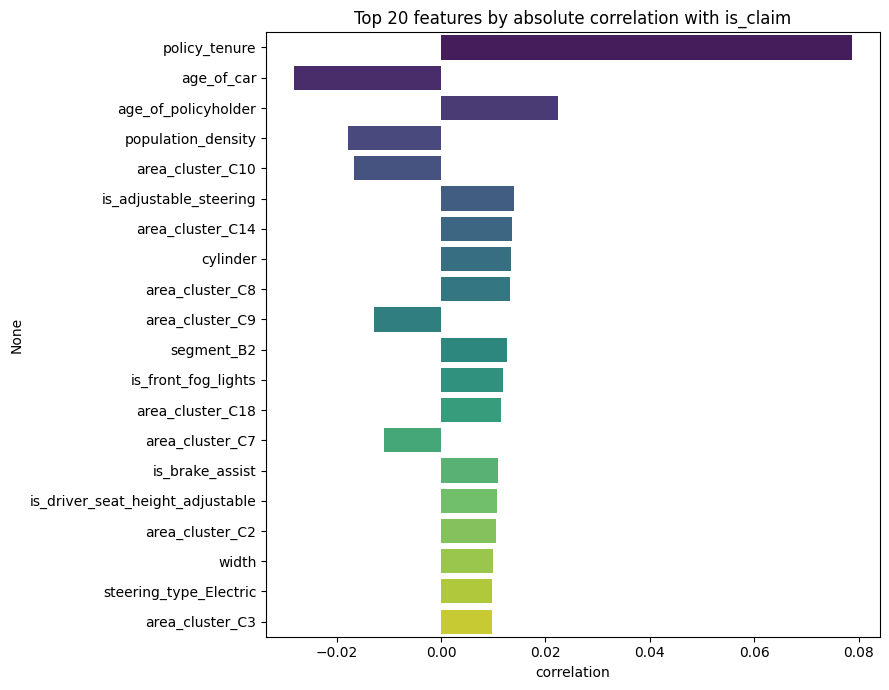

In [4]:
plt.figure(figsize=(9, 7))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title('Top 20 features by absolute correlation with is_claim')
plt.xlabel('correlation')
plt.tight_layout()
plt.show()

### Near constant / low variance features

One hot encoding can create sparse columns where almost every row has the same value (a rare category). These add noise without helping the model, so it is worth flagging them.

In [5]:
variances = X.var().sort_values()
low_variance = variances[variances < 0.01]
print('Low variance columns:', len(low_variance))
low_variance.head(10)

Low variance columns: 8


area_cluster_C20                         0.001857
area_cluster_C22                         0.003520
area_cluster_C18                         0.004113
model_M11                                0.006157
engine_type_1.5 Turbocharged Revotron    0.006157
area_cluster_C21                         0.006427
area_cluster_C16                         0.006797
area_cluster_C17                         0.008327
dtype: float64

### Feature importance from a Random Forest

Training a quick Random Forest on the full feature set and reading off `feature_importances_` is a good non-linear check - it can pick up interactions that plain correlation misses.

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [7]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(20)
top_importances

policy_tenure          0.349579
age_of_car             0.226334
age_of_policyholder    0.118544
population_density     0.033909
power_bhp              0.011970
area_cluster_C10       0.011868
height                 0.010738
torque_nm              0.009960
length                 0.009603
displacement           0.009156
width                  0.008214
gross_weight           0.007645
turning_radius         0.007361
area_cluster_C9        0.007015
area_cluster_C7        0.006377
area_cluster_C3        0.006099
area_cluster_C14       0.005834
area_cluster_C8        0.005802
area_cluster_C2        0.005685
area_cluster_C17       0.005501
dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_5316\3972530251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette='mako')


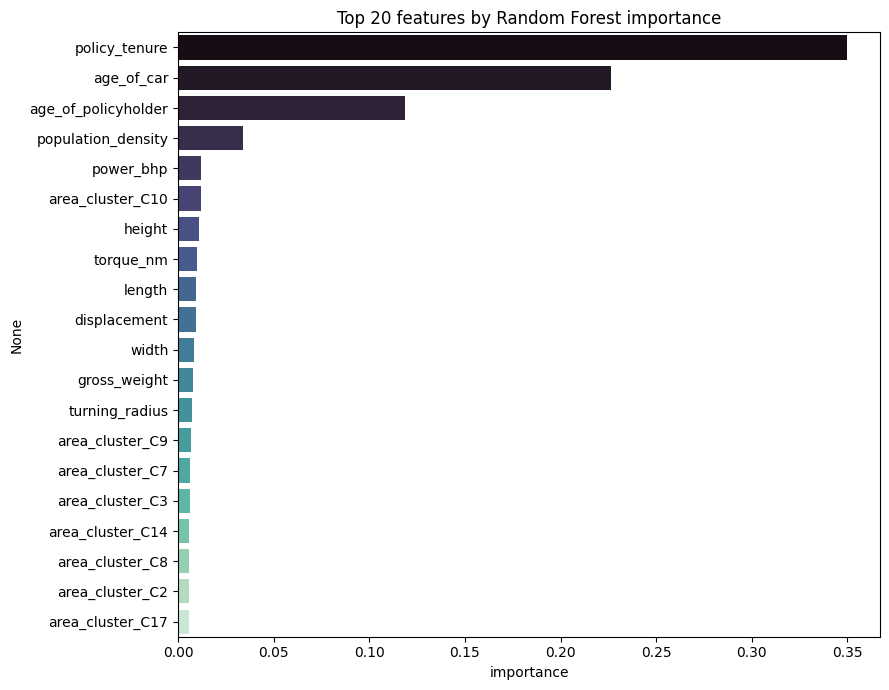

In [8]:
plt.figure(figsize=(9, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, palette='mako')
plt.title('Top 20 features by Random Forest importance')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

### Deciding what to keep

The correlation check and the Random Forest importance check roughly agree on which engineered features matter most (policy tenure, vehicle age/dimensions, torque/power values, population density). None of the low variance one hot columns showed up as important either, which confirms they are safe to leave in without worrying about them dominating the model - tree based models handle sparse one hot columns fine, so the full feature set from notebook 02 is kept for training rather than manually dropping columns.

In [9]:
print('Total features going into training:', X.shape[1])
print('Features with meaningful importance (> 0.001):',
      (importances > 0.001).sum())

Total features going into training: 96
Features with meaningful importance (> 0.001): 67


## Summary

- No features were removed - the imbalance is handled at the model level (`class_weight` / `scale_pos_weight`) instead of trimming the feature set.
- Engineered features (`torque_nm`, `power_bhp`, `policy_tenure`, vehicle dimensions) consistently rank at the top, which validates the feature engineering step.

Next notebook: `04_model_training.ipynb`